In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(735.5), np.float64(1103.5), np.float64(-0.5))

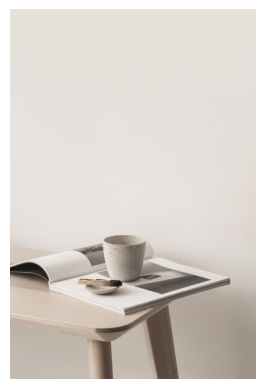

In [3]:
img = cv2.imread('abtract.jpg')
img.shape
img_bgr = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_bgr)
plt.axis("off")

(np.float64(-0.5), np.float64(735.5), np.float64(1103.5), np.float64(-0.5))

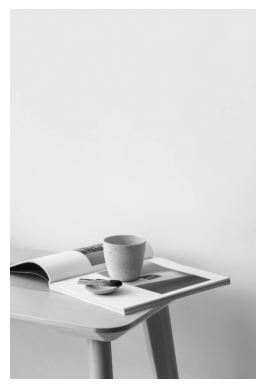

In [4]:
img_gray = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray,cmap='gray')
plt.axis("off")

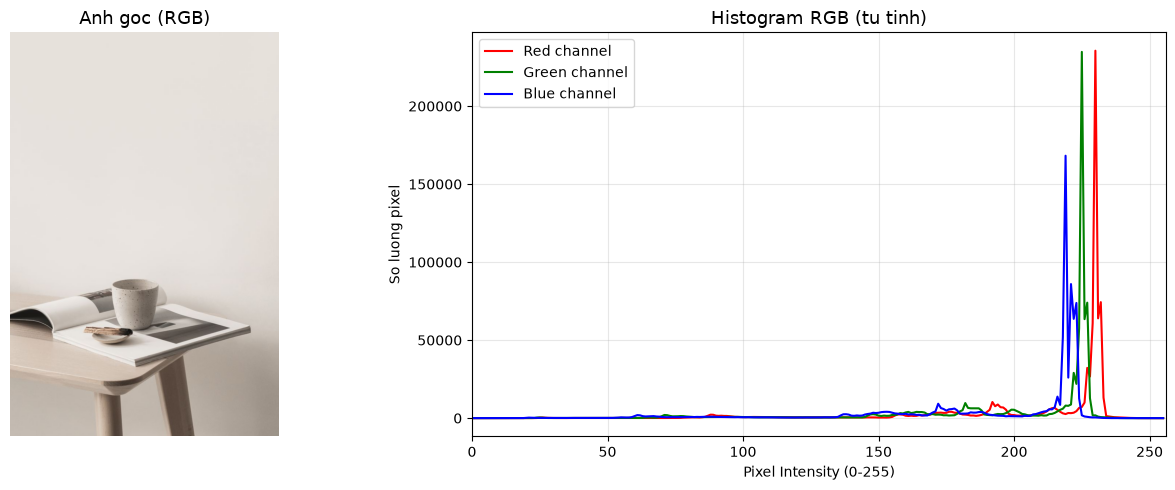

In [5]:
# Tự tính histogram RGB (không dùng cv2.calcHist)
def calc_histogram(image, channel):
    """Tính histogram thủ công bằng cách đếm số pixel tại mỗi mức intensity"""
    hist = [0] * 256
    channel_data = image[:, :, channel]  # Lấy kênh màu
    for row in channel_data:
        for pixel_val in row:
            hist[pixel_val] += 1
    return hist

# Tính histogram cho 3 kênh R, G, B
hist_r = calc_histogram(img_bgr, 0)  # Red
hist_g = calc_histogram(img_bgr, 1)  # Green
hist_b = calc_histogram(img_bgr, 2)  # Blue

# Vẽ kết quả
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_bgr)
axes[0].set_title("Anh goc (RGB)", fontsize=13)
axes[0].axis("off")

axes[1].plot(hist_r, color="red",   label="Red channel",   linewidth=1.5)
axes[1].plot(hist_g, color="green", label="Green channel", linewidth=1.5)
axes[1].plot(hist_b, color="blue",  label="Blue channel",  linewidth=1.5)
axes[1].set_title("Histogram RGB (tu tinh)", fontsize=13)
axes[1].set_xlabel("Pixel Intensity (0-255)")
axes[1].set_ylabel("So luong pixel")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

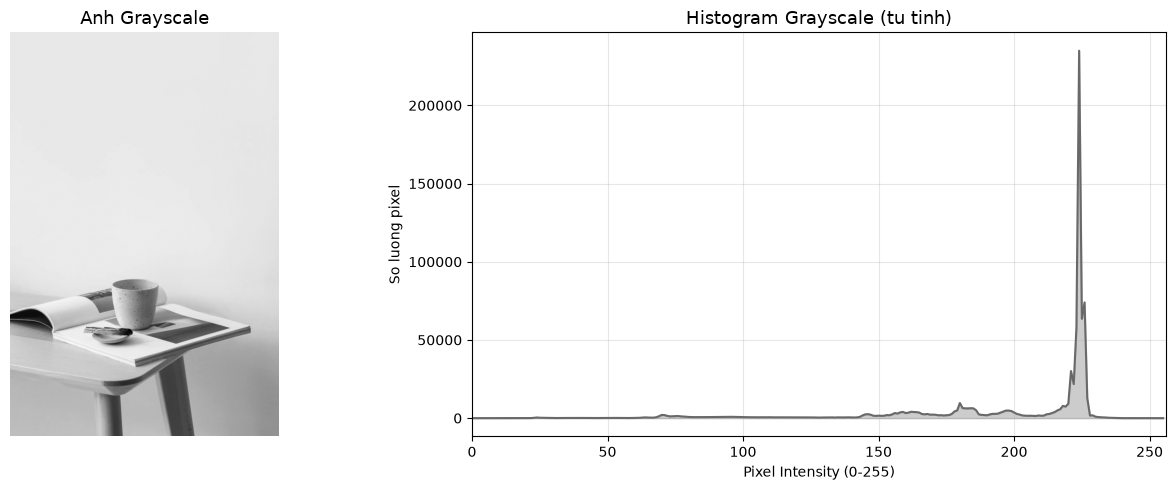

In [6]:
# Tự tính histogram Grayscale (không dùng cv2.calcHist)
def calc_histogram_gray(gray_image):
    """Tính histogram ảnh grayscale bằng cách đếm số pixel tại mỗi mức intensity"""
    hist = [0] * 256
    for row in gray_image:
        for pixel_val in row:
            hist[pixel_val] += 1
    return hist

# Tính histogram grayscale
hist_gray = calc_histogram_gray(img_gray)

# Vẽ kết quả
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Anh Grayscale", fontsize=13)
axes[0].axis("off")

axes[1].plot(hist_gray, color="dimgray", linewidth=1.5)
axes[1].fill_between(range(256), hist_gray, alpha=0.4, color="gray")
axes[1].set_title("Histogram Grayscale (tu tinh)", fontsize=13)
axes[1].set_xlabel("Pixel Intensity (0-255)")
axes[1].set_ylabel("So luong pixel")
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

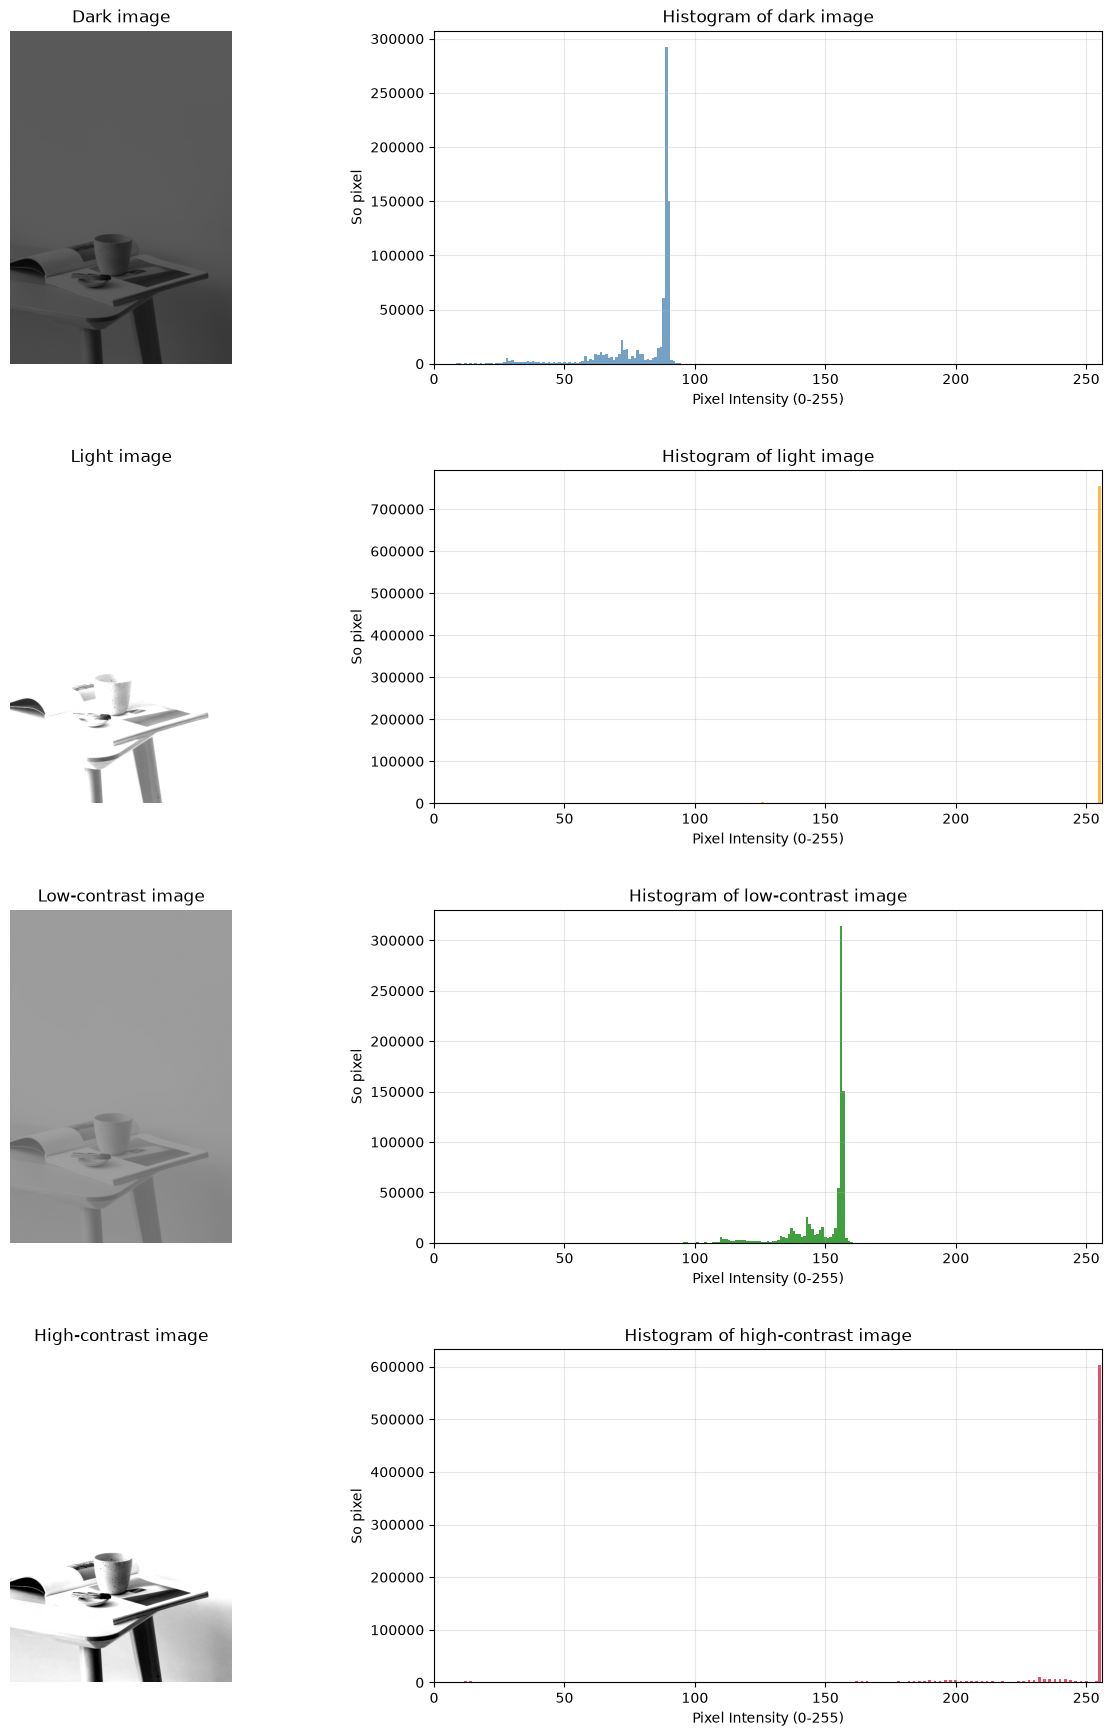

In [7]:
# ============================================================
# Tu tinh va ve histogram sau khi thay doi sac do anh
# Khong dung ham co san - tu xu ly tung pixel
# ============================================================

def calc_histogram_gray(gray_image):
    """Tinh histogram thu cong bang cach dem pixel"""
    hist = [0] * 256
    for row in gray_image:
        for pixel_val in row:
            hist[int(pixel_val)] += 1
    return hist


def adjust_image(gray_image, mode):
    """
    Thay doi sac do anh thu cong:
    - dark:         nhan pixel * 0.4  (lam toi)
    - light:        nhan pixel * 1.8  (lam sang)
    - low_contrast: dua pixel ve gan trung tam 128 (thu hep dai dong)
    - high_contrast: keo pixel ra xa trung tam 128 (mo rong dai dong)
    """
    h, w = gray_image.shape
    result = [[0] * w for _ in range(h)]

    for i in range(h):
        for j in range(w):
            val = int(gray_image[i, j])

            if mode == "dark":
                new_val = val * 0.4
            elif mode == "light":
                new_val = val * 1.8
            elif mode == "low_contrast":
                # Keo pixel lai gan muc trung (128): thu hep contrast
                new_val = 128 + (val - 128) * 0.3
            elif mode == "high_contrast":
                # Keo pixel ra xa muc trung (128): tang contrast
                new_val = 128 + (val - 128) * 2.0

            # Clip ve khoang [0, 255]
            result[i][j] = max(0, min(255, int(new_val)))

    # Chuyen ve numpy array
    import numpy as np
    return np.array(result, dtype=np.uint8)


# Tao 4 phien ban anh
img_dark         = adjust_image(img_gray, "dark")
img_light        = adjust_image(img_gray, "light")
img_low_contrast = adjust_image(img_gray, "low_contrast")
img_high_contrast= adjust_image(img_gray, "high_contrast")

# Tinh histogram cho tung phien ban
hist_dark         = calc_histogram_gray(img_dark)
hist_light        = calc_histogram_gray(img_light)
hist_low_contrast = calc_histogram_gray(img_low_contrast)
hist_high_contrast= calc_histogram_gray(img_high_contrast)

# Ve tat ca
configs = [
    (img_dark,          hist_dark,          "Dark image",         "steelblue"),
    (img_light,         hist_light,         "Light image",        "orange"),
    (img_low_contrast,  hist_low_contrast,  "Low-contrast image", "green"),
    (img_high_contrast, hist_high_contrast, "High-contrast image","crimson"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for row, (img, hist, title, color) in enumerate(configs):
    # Cot trai: hien thi anh
    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(title, fontsize=12)
    axes[row, 0].axis("off")

    # Cot phai: ve histogram
    axes[row, 1].bar(range(256), hist, color=color, alpha=0.75, width=1)
    axes[row, 1].set_title(f"Histogram of {title.lower()}", fontsize=12)
    axes[row, 1].set_xlabel("Pixel Intensity (0-255)")
    axes[row, 1].set_ylabel("So pixel")
    axes[row, 1].set_xlim([0, 256])
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

Kiem tra ma tran nho: OK


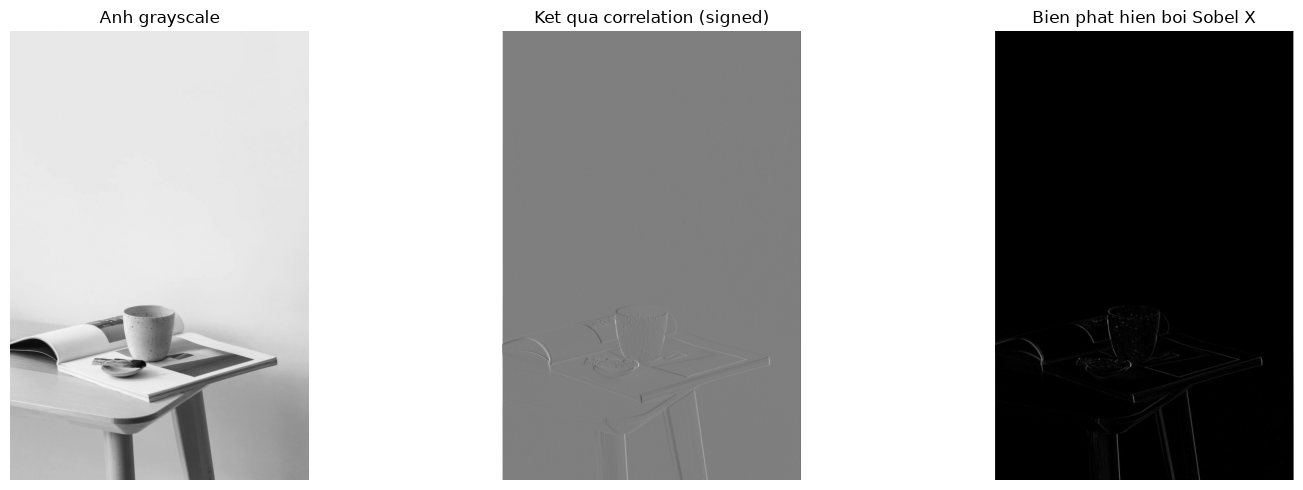

In [9]:
# ============================================================
# Tinh correlation 2D thu cong theo cong thuc trong slide:
# g(x, y) = sum_{s=-a..a} sum_{t=-b..b} w(s, t) f(x+s, y+t)
# Luu y: cong thuc nay la correlation (kernel khong bi lat).
# ============================================================

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


if "img_gray" not in globals():
    image_path = Path("abtract.jpg")
    if not image_path.exists():
        image_path = Path("test_image_processing/abtract.jpg")
    input_image = cv2.imread(str(image_path))
    if input_image is None:
        raise FileNotFoundError(f"Khong tim thay anh: {image_path}")
    img_gray = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)


def correlation_2d(image, kernel):
    """Tinh correlation 2D voi zero padding, khong dung ham loc co san."""
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    if image.ndim != 2:
        raise ValueError("image phai la anh grayscale 2 chieu")
    if kernel.ndim != 2 or kernel.shape[0] % 2 == 0 or kernel.shape[1] % 2 == 0:
        raise ValueError("kernel phai la ma tran 2 chieu co kich thuoc le")

    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded = np.pad(
        image,
        ((pad_height, pad_height), (pad_width, pad_width)),
        mode="constant",
        constant_values=0,
    )
    result = np.zeros_like(image, dtype=np.float32)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            total = 0.0
            for kernel_row in range(kernel_height):
                for kernel_col in range(kernel_width):
                    total += (
                        kernel[kernel_row, kernel_col]
                        * padded[row + kernel_row, col + kernel_col]
                    )
            result[row, col] = total

    return result


# Kiem tra nhanh voi ma tran nho de xac nhan dung cong thuc.
test_image = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
], dtype=np.float32)
test_kernel = np.ones((3, 3), dtype=np.float32)
test_result = correlation_2d(test_image, test_kernel)
assert test_result[1, 1] == 45, "Sai tong 3x3 tai pixel trung tam"
print("Kiem tra ma tran nho: OK")


# Ap dung tren anh dau vao img_gray voi kernel Sobel theo truc x.
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float32)

img_convolution = correlation_2d(img_gray, sobel_x)

# Chuan hoa ket qua signed de hien thi duoc ca bien am va bien duong.
img_convolution_display = cv2.normalize(
    np.abs(img_convolution), None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Anh grayscale")
axes[0].axis("off")

axes[1].imshow(img_convolution, cmap="gray")
axes[1].set_title("Ket qua correlation (signed)")
axes[1].axis("off")

axes[2].imshow(img_convolution_display, cmap="gray")
axes[2].set_title("Bien phat hien boi Sobel X")
axes[2].axis("off")

plt.tight_layout()
plt.show()


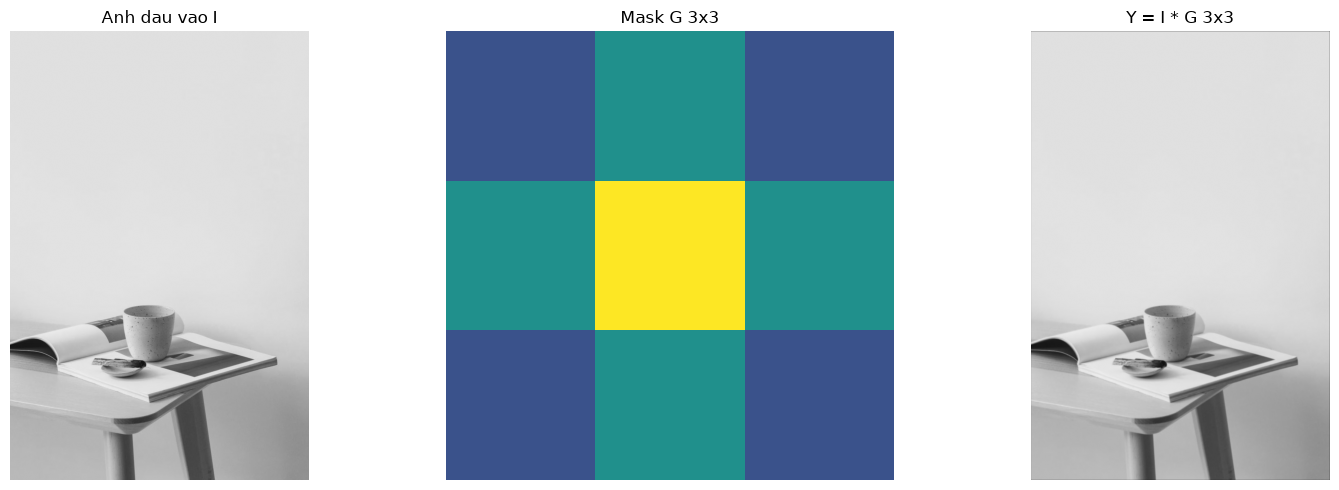

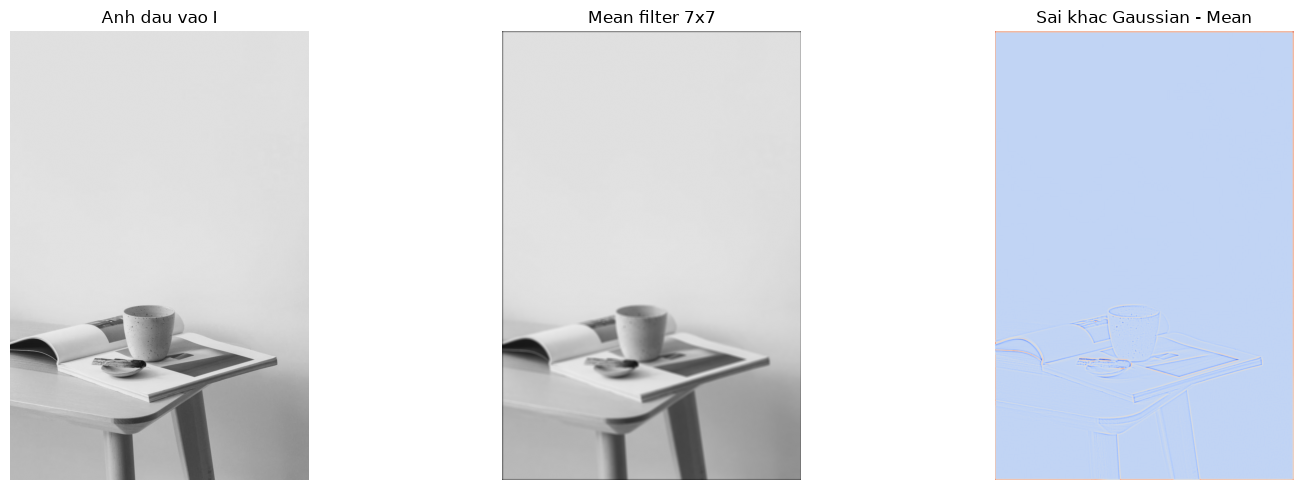

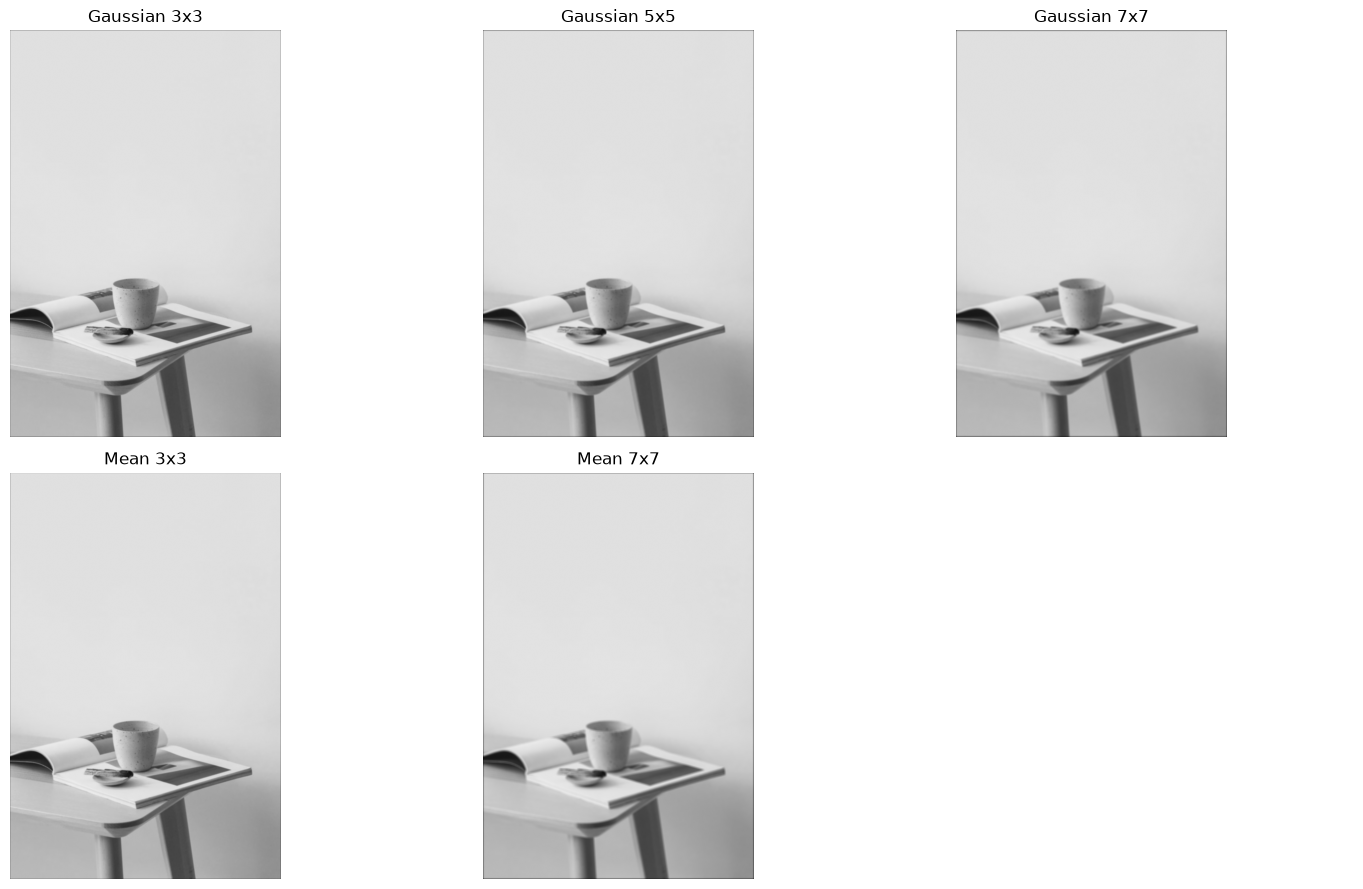

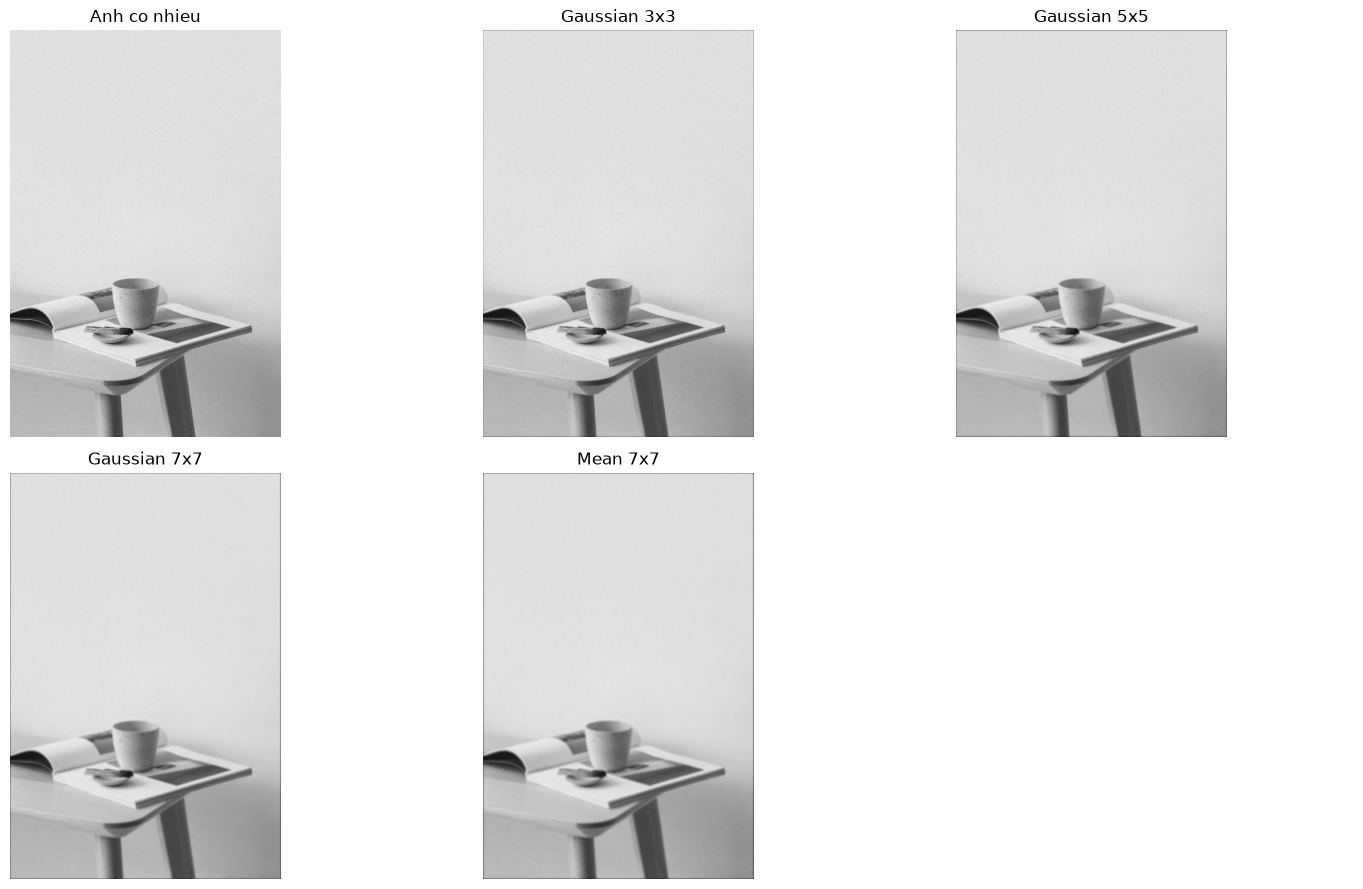

Do lech chuan nhieu: 5.00
Nhan xet: kernel lon lam tron anh manh hon va giam nhieu tot hon, nhung lam mat chi tiet va bien anh.


In [ ]:
def convolution_2d(image, kernel):
    """Tinh convolution 2D thu cong voi zero padding."""
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    if image.ndim != 2:
        raise ValueError("image phai la anh grayscale 2 chieu")
    if kernel.ndim != 2 or kernel.shape[0] % 2 == 0 or kernel.shape[1] % 2 == 0:
        raise ValueError("kernel phai co 2 chieu va kich thuoc le")

    # Convolution khac correlation o cho kernel bi lat 180 do.
    flipped_kernel = np.flip(kernel)
    kernel_height, kernel_width = flipped_kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded = np.pad(
        image,
        ((pad_height, pad_height), (pad_width, pad_width)),
        mode="constant",
        constant_values=0,
    )
    result = np.zeros_like(image, dtype=np.float32)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            image_region = padded[
                row:row + kernel_height,
                col:col + kernel_width,
            ]
            result[row, col] = np.sum(image_region * flipped_kernel)

    return result


def gaussian_kernel(size, sigma=None):
    if size % 2 == 0:
        raise ValueError("size phai la so le")
    if sigma is None:
        sigma = size / 3

    radius = size // 2
    axis = np.arange(-radius, radius + 1, dtype=np.float32)
    x, y = np.meshgrid(axis, axis)
    kernel = np.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


def mean_kernel(size):
    if size % 2 == 0:
        raise ValueError("size phai la so le")
    return np.ones((size, size), dtype=np.float32) / (size * size)


# 1a. Gaussian mask dung dung theo de bai.
gaussian_3x3 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1],
], dtype=np.float32) / 16

img_gaussian_3x3 = convolution_2d(img_gray, gaussian_3x3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Anh dau vao I")
axes[0].axis("off")
axes[1].imshow(gaussian_3x3, cmap="viridis", vmin=0, vmax=gaussian_3x3.max())
axes[1].set_title("Mask G 3x3")
axes[1].axis("off")
axes[2].imshow(img_gaussian_3x3, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Y = I * G 3x3")
axes[2].axis("off")
plt.tight_layout()
plt.show()


# 1b. So sanh voi mean filter G = ones(7,7) / 49.
mean_7x7 = mean_kernel(7)
img_mean_7x7 = convolution_2d(img_gray, mean_7x7)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Anh dau vao I")
axes[0].axis("off")
axes[1].imshow(img_mean_7x7, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Mean filter 7x7")
axes[1].axis("off")
axes[2].imshow(img_gaussian_3x3 - img_mean_7x7, cmap="coolwarm")
axes[2].set_title("Sai khac Gaussian - Mean")
axes[2].axis("off")
plt.tight_layout()
plt.show()


# 1c. Thu nhieu kich thuoc va hai loai bo loc.
filter_results = {
    "Gaussian 3x3": convolution_2d(img_gray, gaussian_kernel(3)),
    "Gaussian 5x5": convolution_2d(img_gray, gaussian_kernel(5)),
    "Gaussian 7x7": convolution_2d(img_gray, gaussian_kernel(7)),
    "Mean 3x3": convolution_2d(img_gray, mean_kernel(3)),
    "Mean 7x7": img_mean_7x7,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for axis, (title, filtered_image) in zip(axes, filter_results.items()):
    axis.imshow(filtered_image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


# 1d. Them nhieu Gaussian sigma = 5 va loc lai bang cac mask.
rng = np.random.default_rng(42)
noise = rng.normal(loc=0, scale=5, size=img_gray.shape)
noisy_image = np.clip(img_gray.astype(np.float32) + noise, 0, 255)

noisy_results = {
    "Anh co nhieu": noisy_image,
    "Gaussian 3x3": convolution_2d(noisy_image, gaussian_kernel(3)),
    "Gaussian 5x5": convolution_2d(noisy_image, gaussian_kernel(5)),
    "Gaussian 7x7": convolution_2d(noisy_image, gaussian_kernel(7)),
    "Mean 7x7": convolution_2d(noisy_image, mean_kernel(7)),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for axis, (title, filtered_image) in zip(axes, noisy_results.items()):
    axis.imshow(filtered_image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

print(f"Do lech chuan nhieu: {noise.std():.2f}")
print("Nhan xet: kernel lon lam tron anh manh hon va giam nhieu tot hon, nhung lam mat chi tiet va bien anh.")


Ma tran anh dau vao:
[[ 10  20  30  40  50]
 [ 60  70  80  90 100]
 [110 120 130 140 150]
 [160 170 180 190 200]
 [210 220 230 240 250]]

Ma tran kernel Gaussian 3x3:
[[0.06 0.12 0.06]
 [0.12 0.25 0.12]
 [0.06 0.12 0.06]]

Ma tran anh dau ra:
[[ 16.88  27.5   35.    42.5   35.62]
 [ 47.5   70.    80.    90.    72.5 ]
 [ 85.   120.   130.   140.   110.  ]
 [122.5  170.   180.   190.   147.5 ]
 [110.62 152.5  160.   167.5  129.38]]

Kiem tra pixel trung tam: 130.00 = 130.00 -> OK

Ma tran 5x5 tai trung tam anh dau vao abtract.jpg:
[[227 227 227 227 227]
 [227 227 227 227 227]
 [227 227 227 227 227]
 [227 227 227 227 227]
 [227 227 227 227 227]]

Ma tran 5x5 dau ra tuong ung:
[[227. 227. 227. 227. 227.]
 [227. 227. 227. 227. 227.]
 [227. 227. 227. 227. 227.]
 [227. 227. 227. 227. 227.]
 [227. 227. 227. 227. 227.]]


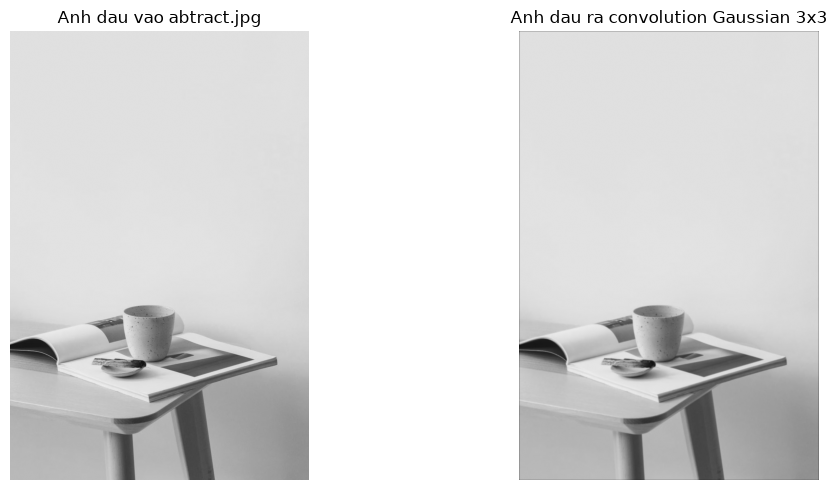

In [ ]:



def convolution_2d_formula(image, kernel):
    """Tinh convolution bang vong lap theo cong thuc, voi zero padding."""
    image = np.asarray(image, dtype=np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    if image.ndim != 2:
        raise ValueError("image phai la anh grayscale 2 chieu")
    if kernel.ndim != 2:
        raise ValueError("kernel phai la ma tran 2 chieu")
    if kernel.shape[0] % 2 == 0 or kernel.shape[1] % 2 == 0:
        raise ValueError("kernel phai co kich thuoc le")

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    half_height = kernel_height // 2
    half_width = kernel_width // 2
    result = np.zeros((image_height, image_width), dtype=np.float32)

    for x in range(image_height):
        for y in range(image_width):
            total = 0.0
            for s in range(-half_height, half_height + 1):
                for t in range(-half_width, half_width + 1):
                    image_x = x + s
                    image_y = y + t
                    kernel_x = s + half_height
                    kernel_y = t + half_width

                    if 0 <= image_x < image_height and 0 <= image_y < image_width:
                        total += kernel[kernel_x, kernel_y] * image[image_x, image_y]

            result[x, y] = total

    return result


# Ma tran nho de in ket qua cu the va kiem tra cong thuc.
small_image = np.array([
    [10, 20, 30, 40, 50],
    [60, 70, 80, 90, 100],
    [110, 120, 130, 140, 150],
    [160, 170, 180, 190, 200],
    [210, 220, 230, 240, 250],
], dtype=np.float32)
small_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1],
], dtype=np.float32) / 16
small_output = convolution_2d_formula(small_image, small_kernel)

np.set_printoptions(precision=2, suppress=True)
print("Ma tran anh dau vao:")
print(small_image.astype(np.uint8))
print("\nMa tran kernel Gaussian 3x3:")
print(small_kernel)
print("\nMa tran anh dau ra:")
print(small_output)

center_value = (
    1 * 70 + 2 * 80 + 1 * 90
    + 2 * 120 + 4 * 130 + 2 * 140
    + 1 * 170 + 2 * 180 + 1 * 190
) / 16
assert np.isclose(small_output[2, 2], center_value)
print(f"\nKiem tra pixel trung tam: {small_output[2, 2]:.2f} = {center_value:.2f} -> OK")


# Ap dung cung cong thuc tren anh dau vao da co san.
image_kernel = small_kernel
image_output = convolution_2d_formula(img_gray, image_kernel)

# In ma tran mot vung 5x5 de ket qua anh that van de doc.
preview_size = 5
preview_start_x = img_gray.shape[0] // 2 - preview_size // 2
preview_start_y = img_gray.shape[1] // 2 - preview_size // 2
preview_input = img_gray[
    preview_start_x:preview_start_x + preview_size,
    preview_start_y:preview_start_y + preview_size,
]
preview_output = image_output[
    preview_start_x:preview_start_x + preview_size,
    preview_start_y:preview_start_y + preview_size,
]

print("\nMa tran 5x5 tai trung tam anh dau vao abtract.jpg:")
print(preview_input)
print("\nMa tran 5x5 dau ra tuong ung:")
print(preview_output)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Anh dau vao abtract.jpg")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(image_output, 0, 255), cmap="gray", vmin=0, vmax=255)
plt.title("Anh dau ra convolution Gaussian 3x3")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# In day du ma tran anh dau vao grayscale abtract.jpg.
# Moi phan tu la gia tri muc xam trong khoang [0, 255].
np.set_printoptions(threshold=np.inf, linewidth=200)
print("Kich thuoc ma tran anh dau vao:", img_gray.shape)
print("Ma tran anh dau vao grayscale:")
print(img_gray)


Kich thuoc ma tran anh dau vao: (1104, 736)
Ma tran anh dau vao grayscale:
[[224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224
  224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224
  224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224
  224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224
  224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224 224